# Setup

This notebook requires:
- [DeepFurniture Dataset](https://huggingface.co/datasets/byliu/DeepFurniture#using-the-dataset) downloaded and uncompressed to `./data/DeepFurniture/uncompressed_data`
- Repository [Depth-Anything-V2](https://github.com/DepthAnything/Depth-Anything-V2?tab=readme-ov-file#usage) cloned at `./DepthAnythingV2`
- Depth-Anything-V2 [pre-trained models](https://github.com/DepthAnything/Depth-Anything-V2?tab=readme-ov-file#pre-trained-models) downloaded to `./DepthAnythingV2/checkpoints`

In [1]:
import os
import time
import random

import cv2
import numpy as np
import pandas as pd

import csv

import wandb

import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader, Subset

import torchvision.transforms as T
import torch.nn as nn
import torch.nn.functional as F

from tqdm import tqdm
from pathlib import Path

from accelerate import Accelerator
from accelerate.utils import set_seed
from accelerate import notebook_launcher
from accelerate import DistributedDataParallelKwargs

import transformers

import h5py

from PIL import Image

# from DepthAnythingV2.depth_anything_v2.dpt import DepthAnythingV2
from DepthAnythingV2.metric_depth.depth_anything_v2.dpt import DepthAnythingV2

# reference to cloned repository
from data.DeepFurniture.deepfurniture import DeepFurnitureDataset


DEVICE = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'

c:\Users\timon\.pyenv-win-venv\envs\dspro2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
xFormers not available
xFormers not available


In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.mps.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED) 

In [3]:
wandb.login()

wandb: Currently logged in as: timon-schmid (timon-schmid-hochschule-luzern) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

# Preprocessing & Dataset

In [4]:
base_dataset = DeepFurnitureDataset("./data/DeepFurniture/uncompressed_data")

## Data Analysis

In [ ]:
RUN_DATA_ANALYSIS = False

if RUN_DATA_ANALYSIS:
    with open('depth_statistics.csv', mode='w', newline='') as file:
        writer = csv.DictWriter(file, fieldnames=['image_id', 'min_depth', 'max_depth', 'mean_depth', 'std_depth', 'median_depth', 'depth_range'])
        writer.writeheader()

        for idx, sample in enumerate(tqdm(base_dataset)):
            try:
                depth_array = np.array(sample['depth']).flatten()
                image_id = sample['scene_id']

                writer.writerow({
                    'image_id': image_id,
                    'min_depth': np.min(depth_array),
                    'max_depth': np.max(depth_array),
                    'mean_depth': np.mean(depth_array),
                    'std_depth': np.std(depth_array),
                    'median_depth': np.median(depth_array),
                    'depth_range': np.max(depth_array) - np.min(depth_array)
                })

            except Exception as e:
                print(f"Error processing sample {idx}: {e}")

In [ ]:
df = pd.read_csv('depth_statistics.csv')
df.head()

In [ ]:
# List of depth statistic columns to plot
depth_metrics = ['min_depth', 'max_depth', 'mean_depth', 'std_depth', 'median_depth', 'depth_range']

# Set up the figure and axes
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

# Generate histograms for each metric
for idx, metric in enumerate(depth_metrics):
    axes[idx].hist(df[metric], bins=30, edgecolor='black')
    axes[idx].set_title(f'Histogram of {metric}')
    axes[idx].set_xlabel(metric)
    axes[idx].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [ ]:
# List of depth metric columns
depth_metrics = ['min_depth', 'max_depth', 'mean_depth', 'std_depth', 'median_depth', 'depth_range']

# Create a boxplot
plt.figure(figsize=(12, 6))
plt.boxplot([df[metric] for metric in depth_metrics], labels=depth_metrics, vert=True)

# Add titles and labels
plt.title('Box Plots of Depth Statistics')
plt.ylabel('Depth Value')
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
df.sort_values(by='max_depth', ascending=False).head()

In [ ]:
scenes_root = r'C:\\Users\\timon\\git\\HSLU.DSPRO2.Beyond2D\\data\\DeepFurniture\\uncompressed_data\\scenes'

# Sort by max_depth in descending order and get top 5 entries
top_images = df.sort_values(by='max_depth', ascending=False).head(5)

# Create a 2-row subplot: top = RGB, bottom = Depth
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(18, 6))

for i, row in enumerate(top_images.itertuples(), start=0):
    image_id = row.image_id
    folder_path = os.path.join(scenes_root, str(image_id))
    rgb_path = os.path.join(folder_path, 'image.jpg')
    depth_path = os.path.join(folder_path, 'depth.png')

    # Load and plot RGB image
    if os.path.exists(rgb_path):
        rgb_img = Image.open(rgb_path)
        axes[0, i].imshow(rgb_img)
        axes[0, i].set_title(f'{image_id}\nMax: {row.max_depth:.2f} | Mean: {row.mean_depth:.2f}')
        axes[0, i].axis('off')
    else:
        axes[0, i].set_visible(False)
        print(f"RGB image not found: {rgb_path}")

    # Load and plot depth image (as grayscale)
    if os.path.exists(depth_path):
        depth_img = Image.open(depth_path)
        axes[1, i].imshow(depth_img, cmap='plasma')
        axes[1, i].axis('off')
    else:
        axes[1, i].set_visible(False)
        print(f"Depth image not found: {depth_path}")

plt.tight_layout()
plt.show()

In [ ]:
# Filter out entries with max_depth > 20000
df_filtered = df[df['max_depth'] <= 20000]

# List of depth metric columns to plot
depth_metrics = ['min_depth', 'max_depth', 'mean_depth', 'std_depth', 'median_depth', 'depth_range']

# Create boxplot
plt.figure(figsize=(12, 6))
plt.boxplot([df_filtered[metric] for metric in depth_metrics], labels=depth_metrics, vert=True)

# Add titles and labels
plt.title('Box Plots of Depth Statistics (Filtered: max_depth ≤ 20,000)')
plt.ylabel('Depth Value')
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
scenes_root = r'C:\\Users\\timon\\git\\HSLU.DSPRO2.Beyond2D\\data\\DeepFurniture\\uncompressed_data\\scenes'

# Sort by max_depth in descending order and get top 5 entries
top_images = df_filtered.sort_values(by='max_depth', ascending=False).head(5)

# Create a 2-row subplot: top = RGB, bottom = Depth
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(18, 6))

for i, row in enumerate(top_images.itertuples(), start=0):
    image_id = row.image_id
    folder_path = os.path.join(scenes_root, str(image_id))
    rgb_path = os.path.join(folder_path, 'image.jpg')
    depth_path = os.path.join(folder_path, 'depth.png')

    # Load and plot RGB image
    if os.path.exists(rgb_path):
        rgb_img = Image.open(rgb_path)
        axes[0, i].imshow(rgb_img)
        axes[0, i].set_title(f'{image_id}\nMax: {row.max_depth:.2f} | Mean: {row.mean_depth:.2f}')
        axes[0, i].axis('off')
    else:
        axes[0, i].set_visible(False)
        print(f"RGB image not found: {rgb_path}")

    # Load and plot depth image (as grayscale)
    if os.path.exists(depth_path):
        depth_img = Image.open(depth_path)
        axes[1, i].imshow(depth_img, cmap='plasma')
        axes[1, i].axis('off')
    else:
        axes[1, i].set_visible(False)
        print(f"Depth image not found: {depth_path}")

plt.tight_layout()
plt.show()

## Data Split

In [5]:
class HDF5Dataset(Dataset):
    def __init__(self, h5_path):
        self.h5_path = h5_path
        with h5py.File(self.h5_path, 'r') as f:
            self.keys = list(f.keys())

    def __getitem__(self, index):
        if not hasattr(self, 'file') or self.file is None:
            self.file = h5py.File(self.h5_path, 'r')

        grp = self.file[self.keys[index]]
        image = torch.tensor(grp["image"][:])
        depth = torch.tensor(grp["depth"][:])
        return {"image": image, "depth": depth}

    def __len__(self):
        return len(self.keys)

In [6]:
def collate_fn(batch):
    return [item for item in batch if item is not None]

In [7]:
def preprocess_dataset_hdf5(dataset, split, image_size=(392, 392), max_depth_threshold=20000):
    transform_image = T.Compose([
        T.Resize(image_size),
        T.ToTensor(),
        T.Normalize(mean=[0.5] * 3, std=[0.5] * 3)
    ])

    transform_depth = T.Compose([
        T.Resize(image_size),
        T.ToTensor()
    ])

    h5_path = f"processed_{split}_dataset_scaled_absolute_depths_max_20.h5"
    with h5py.File(h5_path, "w") as h5f:
        idx = 0
        for data in tqdm(dataset, desc=f"Preprocessing {split}"):
            try:
                if not data['image'] or not data['depth']:
                    continue

                # Convert depth to tensor early to compute max
                depth = transform_depth(data['depth'])  # Shape: (1, H, W)
                max_depth = depth.max().item()  # Get the max depth value

                if max_depth > max_depth_threshold:
                    continue  # Skip outliers

                # Scale depth: convert from raw units (e.g., mm) to meters (0–20 range)
                scaled_depth = depth / 1000.0

                image = transform_image(data['image'])

                grp = h5f.create_group(f"sample_{idx}")
                grp.create_dataset("image", data=image.numpy(), compression="gzip")
                grp.create_dataset("depth", data=scaled_depth.numpy(), compression="gzip")

                idx += 1

            except Exception as e:
                print(f"Skipping corrupted sample: {e}")
                continue

    print(f"Saved HDF5 to: {h5_path}")


In [8]:
RUN_PREPROCESSING = False

if RUN_PREPROCESSING:
    # Split indices
    num_samples = len(base_dataset)
    indices = list(range(num_samples))
    random.shuffle(indices)

    train_split = int(0.8 * num_samples)
    val_split = int(0.9 * num_samples)

    train_indices = indices[:train_split]
    val_indices = indices[train_split:val_split]
    test_indices = indices[val_split:]

    # Create subsets
    train_subset = Subset(base_dataset, train_indices)
    val_subset = Subset(base_dataset, val_indices)
    test_subset = Subset(base_dataset, test_indices)

    # Wrap subsets with image/depth transformations
    preprocess_dataset_hdf5(train_subset, 'train')
    preprocess_dataset_hdf5(val_subset, 'val')
    preprocess_dataset_hdf5(test_subset, 'test')



In [9]:
train_dataset = HDF5Dataset("data/DeepFurniture/pytorch/processed_train_dataset_scaled_absolute_depths_max_20.h5")
val_dataset = HDF5Dataset("data/DeepFurniture/pytorch/processed_val_dataset_scaled_absolute_depths_max_20.h5")
test_dataset = HDF5Dataset("data/DeepFurniture/pytorch/processed_test_dataset_scaled_absolute_depths_max_20.h5")

# Model

In [10]:
model_configs = {
    'vits': {'encoder': 'vits', 'features': 64, 'out_channels': [48, 96, 192, 384]},
    'vitb': {'encoder': 'vitb', 'features': 128, 'out_channels': [96, 192, 384, 768]},
    'vitl': {'encoder': 'vitl', 'features': 256, 'out_channels': [256, 512, 1024, 1024]},
    'vitg': {'encoder': 'vitg', 'features': 384, 'out_channels': [1536, 1536, 1536, 1536]}
}

encoder = 'vits' # or 'vits', 'vitb', 'vitg'
dataset = 'hypersim' # 'hypersim' for indoor model, 'vkitti' for outdoor model
max_depth = 20 # 20 for indoor model, 80 for outdoor model

model = DepthAnythingV2(**{**model_configs[encoder], 'max_depth': max_depth})
model.load_state_dict({k: v for k, v in torch.load(f'DepthAnythingV2/checkpoints/depth_anything_v2_metric_{dataset}_{encoder}.pth').items() if 'pretrained' in k}, strict=False)
# model.load_state_dict(torch.load(f'DepthAnythingV2/checkpoints/depth_anything_v2_metric_{dataset}_{encoder}.pth', map_location='cpu'))


_IncompatibleKeys(missing_keys=['depth_head.projects.0.weight', 'depth_head.projects.0.bias', 'depth_head.projects.1.weight', 'depth_head.projects.1.bias', 'depth_head.projects.2.weight', 'depth_head.projects.2.bias', 'depth_head.projects.3.weight', 'depth_head.projects.3.bias', 'depth_head.resize_layers.0.weight', 'depth_head.resize_layers.0.bias', 'depth_head.resize_layers.1.weight', 'depth_head.resize_layers.1.bias', 'depth_head.resize_layers.3.weight', 'depth_head.resize_layers.3.bias', 'depth_head.scratch.layer1_rn.weight', 'depth_head.scratch.layer2_rn.weight', 'depth_head.scratch.layer3_rn.weight', 'depth_head.scratch.layer4_rn.weight', 'depth_head.scratch.refinenet1.out_conv.weight', 'depth_head.scratch.refinenet1.out_conv.bias', 'depth_head.scratch.refinenet1.resConfUnit1.conv1.weight', 'depth_head.scratch.refinenet1.resConfUnit1.conv1.bias', 'depth_head.scratch.refinenet1.resConfUnit1.conv2.weight', 'depth_head.scratch.refinenet1.resConfUnit1.conv2.bias', 'depth_head.scratch.

# Training

In [11]:
def scale_invariant_loss(pred, target):
    pred = pred.view(pred.size(0), -1)
    target = target.view(target.size(0), -1)
    d = torch.log(pred + 1e-6) - torch.log(target + 1e-6)
    return torch.sqrt((d ** 2).mean() - 0.5 * (d.mean()) ** 2)


def berhu_loss(pred, target):
    diff = torch.abs(pred - target)
    c = 0.2 * torch.max(diff).item()
    mask = diff <= c
    l1 = diff[mask]
    l2 = (diff[~mask] ** 2 + c ** 2) / (2 * c)
    return torch.cat([l1, l2]).mean()

In [12]:
def compute_absrel(pred, gt, eps=1e-6):
    valid = gt > eps
    return (torch.abs(pred[valid] - gt[valid]) / gt[valid]).mean().item()

In [13]:
class SiLogLoss(nn.Module):
    def __init__(self, lambd=0.5, eps=1e-6):
        super().__init__()
        self.lambd = lambd
        self.eps = eps  # small number to avoid log(0)

    def forward(self, pred, target, valid_mask):
        # Clamp pred and target to prevent log(0) or log(negative)
        pred = torch.clamp(pred, min=self.eps)
        target = torch.clamp(target, min=self.eps)

        valid_mask = valid_mask.detach()
        pred = pred[valid_mask]
        target = target[valid_mask]

        diff_log = torch.log(target) - torch.log(pred)
        loss = torch.sqrt(
            torch.pow(diff_log, 2).mean() -
            self.lambd * torch.pow(diff_log.mean(), 2)
        )
        return loss

In [14]:
max_depth = 10
batch_size = 11
lr = 5e-6
weight_decay = 0.01
num_epochs = 10
warmup_epochs = 0.5
scheduler_rate = 1
mixed_precision = 'fp16'

load_state = False
state_path = "./accelerator/model"


In [16]:
num_epochs = 20
run_name = f'depthanything-{encoder}-{time.strftime("%Y%m%d-%H%M%S")}'

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    collate_fn=collate_fn
)
val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    collate_fn=collate_fn
)

# optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
optimizer = torch.optim.AdamW([{'params': [param for name, param in model.named_parameters() if 'pretrained' in name], 'lr': lr},
                       {'params': [param for name, param in model.named_parameters() if 'pretrained' not in name], 'lr': lr*10}],
                      lr=lr, weight_decay=weight_decay)

criterion = SiLogLoss() # author's loss

scheduler = transformers.get_cosine_schedule_with_warmup(
    optimizer, 
    num_warmup_steps=len(train_loader) * warmup_epochs, 
    num_training_steps=num_epochs * scheduler_rate * len(train_loader))

model.to(DEVICE)

wandb.init(project="hslu-dspro2-beyond2d", name=run_name, config={
    "epochs": num_epochs,
    "batch_size": train_loader.batch_size,
    "lr": optimizer.param_groups[0]["lr"],
    "encoder": encoder,
})

best_val_absrel = float("inf")

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    total_absrel_train = 0.0
    total_delta1_train = 0.0
    start_time = time.time()

    print(f"\n🚀 Starting Epoch {epoch+1}/{num_epochs}")
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}", leave=False)

    for batch in progress_bar:
        optimizer.zero_grad()

        images = torch.stack([b["image"] for b in batch]).to(DEVICE)
        depths = torch.stack([b["depth"].squeeze(0) for b in batch]).to(DEVICE)

        pred = model(images)

        loss = criterion(pred, depths, (depths <= max_depth) & (depths >= 0.001))

        loss.backward()
        optimizer.step()
        scheduler.step()

        epoch_loss += loss.item()

        valid_mask = (depths <= max_depth) & (depths >= 0.001)
        absrel = compute_absrel(pred[valid_mask], depths[valid_mask])
        total_absrel_train += absrel

        ratio = torch.max(
            pred[valid_mask] / depths[valid_mask].clamp(min=1e-6),
            depths[valid_mask] / pred[valid_mask].clamp(min=1e-6)
        )
        delta1 = (ratio < 1.25).float().mean().item()
        total_delta1_train += delta1

        progress_bar.set_postfix(loss=loss.item(), absRel=absrel, delta1=delta1)

    avg_loss = epoch_loss / len(train_loader)
    avg_absrel_train = total_absrel_train / len(train_loader)
    avg_delta1_train = total_delta1_train / len(train_loader)
    elapsed = time.time() - start_time
    print(f"✅ Epoch {epoch+1} | Loss: {avg_loss:.4f} | absRel: {avg_absrel_train:.4f} | delta1: {avg_delta1_train:.4f} | Time: {elapsed:.2f}s")

    # Validation
    model.eval()
    val_loss = 0.0
    total_absrel_val = 0.0
    total_delta1_val = 0.0

    with torch.no_grad():
        val_bar = tqdm(val_loader, desc="Validation", leave=False)
        for batch in val_bar:
            images = torch.stack([b["image"] for b in batch]).to(DEVICE)
            depths = torch.stack([b["depth"].squeeze(0) for b in batch]).to(DEVICE)

            pred = model(images)

            loss = criterion(pred, depths, (depths <= max_depth) & (depths >= 0.001))

            val_loss += loss.item()

            valid_mask = (depths <= max_depth) & (depths >= 0.001)
            absrel = compute_absrel(pred[valid_mask], depths[valid_mask])
            ratio = torch.max(
                pred[valid_mask] / depths[valid_mask].clamp(min=1e-6),
                depths[valid_mask] / pred[valid_mask].clamp(min=1e-6)
            )
            delta1 = (ratio < 1.25).float().mean().item()

            total_absrel_val += absrel
            total_delta1_val += delta1

            val_bar.set_postfix(loss=loss.item(), absRel=absrel, delta1=delta1)

    avg_val_loss = val_loss / len(val_loader)
    avg_absrel_val = total_absrel_val / len(val_loader)
    avg_delta1_val = total_delta1_val / len(val_loader)
    print(f"🔍 Validation | Loss: {avg_val_loss:.4f} | absRel: {avg_absrel_val:.4f} | delta1: {avg_delta1_val:.4f}")

    wandb.log({
        "train_loss": avg_loss,
        "train_absRel": avg_absrel_train,
        "train_delta1": avg_delta1_train,
        "val_loss": avg_val_loss,
        "val_absRel": avg_absrel_val,
        "val_delta1": avg_delta1_val,
        "epoch": epoch + 1
    })

    if avg_absrel_val < best_val_absrel:
        best_val_absrel = avg_absrel_val
        
    checkpoint_path = Path(f"model_epoch_{epoch}.pth")
    torch.save(model.state_dict(), checkpoint_path)
    print(f"💾 Model saved with absRel={avg_absrel_val:.4f}")

    # Log model as artifact
    artifact = wandb.Artifact(name=f"model-epoch-{epoch+1}", type="model")
    artifact.add_file(str(checkpoint_path))
    wandb.log_artifact(artifact)


wandb.finish()


🚀 Starting Epoch 1/20


✅ Epoch 1 | Loss: 0.3456 | absRel: 0.6366 | delta1: 0.6446 | Time: 454.08s


🔍 Validation | Loss: 0.2511 | absRel: 0.2612 | delta1: 0.7853
💾 Model saved with absRel=0.2612

🚀 Starting Epoch 2/20


✅ Epoch 2 | Loss: 0.2427 | absRel: 0.2609 | delta1: 0.7735 | Time: 449.16s


🔍 Validation | Loss: 0.2419 | absRel: 0.2318 | delta1: 0.7409
💾 Model saved with absRel=0.2318

🚀 Starting Epoch 3/20


...

🔍 Validation | Loss: 0.1924 | absRel: 0.1810 | delta1: 0.8702
💾 Model saved with absRel=0.1810

🚀 Starting Epoch 20/20


✅ Epoch 20 | Loss: 0.0893 | absRel: 0.0846 | delta1: 0.9878 | Time: 435.98s


🔍 Validation | Loss: 0.1924 | absRel: 0.1810 | delta1: 0.8703
💾 Model saved with absRel=0.1810


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train_absRel,█▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
train_delta1,▁▄▅▆▆▇▇▇████████████
train_loss,█▅▄▄▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁
val_absRel,█▅▇▄▅▃▅▃▂▂▂▁▂▁▁▁▁▁▁▁
val_delta1,▃▁▄▃▆▅▆▄▇▇▆▇████████
val_loss,█▇▆▅▄▃▃▃▂▂▂▂▁▁▁▁▁▁▁▁
epoch,20
train_absRel,0.08462
train_delta1,0.98785
train_loss,0.0893


# Evaluation

In [17]:
import gc

del model, train_loader, val_loader, optimizer

gc.collect()

torch.cuda.empty_cache()
torch.cuda.ipc_collect()

In [18]:
encoder = 'vits'

In [19]:
pretrained_model = DepthAnythingV2(**{**model_configs[encoder], 'max_depth': max_depth})
pretrained_model.load_state_dict(torch.load(f'DepthAnythingV2/checkpoints/depth_anything_v2_metric_{dataset}_{encoder}.pth', map_location='cpu'))
pretrained_model = pretrained_model.to(DEVICE).eval()

In [20]:
finetuned_model = DepthAnythingV2(**{**model_configs[encoder], 'max_depth': max_depth})
finetuned_model.load_state_dict(torch.load(f'model_epoch_19.pth', map_location='cpu'))
finetuned_model = finetuned_model.to(DEVICE).eval()

In [21]:
def compute_depth_anything(model, image):
    img_rgb = np.array(image)
    
    # Convert to BGR format for OpenCV
    img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
    
    with torch.no_grad():
        depth_map = model.infer_image(img_bgr)
    
    return depth_map

In [22]:
def convert_tensor_image(image):
    # Convert torch.Tensor to NumPy array if needed
    if isinstance(image, torch.Tensor):
        image = image.permute(1, 2, 0).cpu().numpy()  # CxHxW → HxWxC
        image = (image * 255).astype(np.uint8)  # Rescale if image was normalized

    # Convert to BGR format for OpenCV
    return cv2.cvtColor(image, cv2.COLOR_RGB2BGR)

In [23]:
def compute_depth_anything(model, image):
    img_bgr = convert_tensor_image(image)

    with torch.no_grad():
        depth_map = model.infer_image(img_bgr)

    return depth_map

In [24]:
test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    collate_fn=collate_fn
)

In [25]:
def denormalize_image(tensor):
    # tensor shape: (3, H, W)
    tensor = tensor.clone()
    tensor = tensor * 0.5 + 0.5  # Unnormalize to [0, 1]
    image_np = tensor.permute(1, 2, 0).numpy()  # Convert to (H, W, 3) for matplotlib
    return image_np

def depth_to_numpy(depth_tensor):
    # tensor shape: (1, H, W)
    depth_np = depth_tensor.squeeze().numpy()  # Shape: (H, W)
    return depth_np

In [ ]:
image = None
depth = None

for scene in test_loader:
    image = scene[0]['image']  # Assuming batch size is 1
    depth = scene[0]['depth']

    output_pretrained = compute_depth_anything(pretrained_model, image)
    output_finetuned = compute_depth_anything(finetuned_model, image)
    break  # Remove this line if you want to run through the full test set

image = denormalize_image(image)
depth = depth_to_numpy(depth)

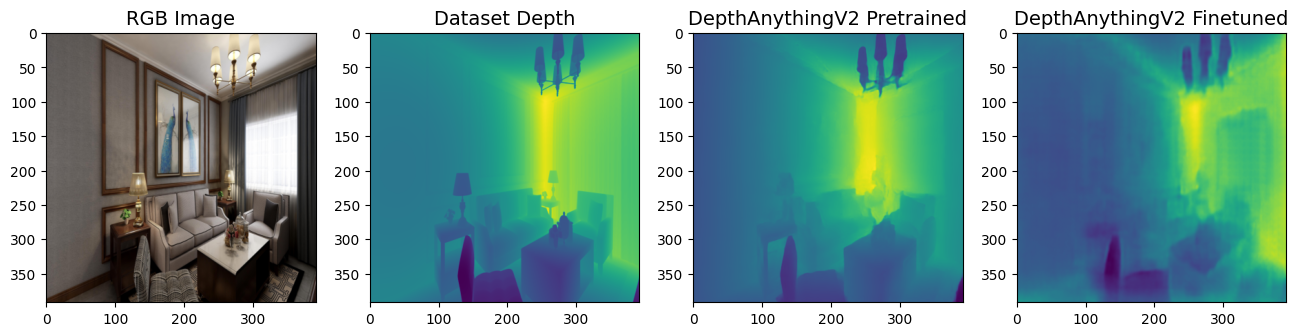

In [33]:
fig, axes = plt.subplots(1, 4, figsize=(16, 8))

axes[0].set_title('RGB Image', fontsize=14)
axes[0].imshow(image)

axes[1].set_title('Dataset Depth', fontsize=14)
axes[1].imshow(depth)

axes[2].set_title('DepthAnythingV2 Pretrained', fontsize=14)
axes[2].imshow(output_pretrained)

axes[3].set_title('DepthAnythingV2 Finetuned', fontsize=14)
axes[3].imshow(output_finetuned)